# pcap → path throughput (tshark + CSV)

**Goal**: plot **Path A / Path B / total all-UDP** Mbps in 1 s bins (per-path pcap, filter `udp` only).

- Each path is captured on its own interface pcap → **total = pathA_all_udp + pathB_all_udp** (per second).
- Do **not** compare `total` to `max(pathA, pathB)`; total should be **≥ each path** and ≈ their sum.
- Down/up directional filters are omitted at this stage (run separately if needed).

**Method**: `tshark -e frame.time_relative -e frame.len`, bin by `floor(frame.time_relative)`, `Mbps = bytes×8/1e6`.

---

VM: `SESSION_DIR = Path("/home/mininet/Project/4D-MAP/logs_exp/session_…/fig7_um_t")`

In [10]:
# Third-party deps (network only on first install)
import importlib.util
import subprocess
import sys

_PACKAGES = ["pandas", "matplotlib"]

def _have(mod: str) -> bool:
    return importlib.util.find_spec(mod) is not None

_missing = [p for p in _PACKAGES if not _have(p)]
if _missing:
    print("Installing:", ", ".join(_missing), flush=True)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--disable-pip-version-check", "--no-input", *_missing],
        timeout=600,
    )
else:
    print("OK:", ", ".join(_PACKAGES))

OK: pandas, matplotlib


In [11]:
import math
import os
import shutil
import subprocess
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except (ImportError, AttributeError):
    os.environ.setdefault("MPLBACKEND", "Agg")


def find_repo() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "scripts" / "analyze" / "parse_logs.py").is_file():
            return p
    return cwd


REPO = find_repo()
print("REPO =", REPO)

REPO = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment


In [12]:
# --- configurable session ---
SESSION_DIR = REPO / "logs_exp" / "session_20260517_233010" / "fig7_um_t"

PCAP_A_NAME = "pathA_h1_20260517_233010.pcap"
PCAP_B_NAME = "pathB_h1_20260517_233010.pcap"

PCAP_A = SESSION_DIR / "pcaps" / PCAP_A_NAME
PCAP_B = SESSION_DIR / "pcaps" / PCAP_B_NAME

OUT_DIR = SESSION_DIR / "csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILTER_A_ALL_UDP = "udp"
FILTER_B_ALL_UDP = "udp"

SECOND_MAX = 420
POST_STEADY_SECOND = 100
PATH_B_ALERT_MBPS = 10.5

CSV_1S = OUT_DIR / "throughput_all_udp_1s.csv"
CSV_10S = OUT_DIR / "throughput_all_udp_10s.csv"
FIG_1S = OUT_DIR / "throughput_all_udp_1s.png"

for p in (PCAP_A, PCAP_B):
    print(p, "exists" if p.is_file() else "MISSING — update SESSION_DIR / names")

assert shutil.which("tshark"), "tshark not on PATH"
print("OUT_DIR =", OUT_DIR)

/Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_20260517_233010/fig7_um_t/pcaps/pathA_h1_20260517_233010.pcap exists
/Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_20260517_233010/fig7_um_t/pcaps/pathB_h1_20260517_233010.pcap exists
OUT_DIR = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_20260517_233010/fig7_um_t/csv


In [13]:

def read_frame_len_bins(pcap: Path, display_filter: str) -> defaultdict:
    """Bin total frame bytes by second index: floor(frame.time_relative)."""
    bins = defaultdict(int)
    cmd = [
        "tshark", "-r", str(pcap), "-Y", display_filter,
        "-T", "fields", "-E", "separator=\t",
        "-e", "frame.time_relative", "-e", "frame.len",
    ]
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr.strip() or "tshark failed")
    for line in proc.stdout.splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2:
            continue
        try:
            si = int(math.floor(float(parts[0])))
            flen = int(parts[1])
        except ValueError:
            continue
        if si >= 0:
            bins[si] += flen
    return bins


def bins_to_mbps_series(bin_dict: defaultdict, *, last_second: int, interval_s: float) -> pd.Series:
    return pd.Series(
        [bin_dict.get(s, 0) * 8 / 1_000_000 / interval_s for s in range(0, last_second + 1)],
        index=range(0, last_second + 1),
        dtype="float64",
    )


def mean_mbps_over_seconds(bin_dict: defaultdict, *, last_second: int, interval_s: float = 1.0) -> float:
    total_bytes = sum(bin_dict.get(s, 0) for s in range(0, last_second + 1))
    duration_s = last_second + 1
    return total_bytes * 8 / 1_000_000 / (duration_s * interval_s) if duration_s > 0 else 0.0


print("Reading pcaps (all UDP only)...", flush=True)
bins_a = read_frame_len_bins(PCAP_A, FILTER_A_ALL_UDP)
bins_b = read_frame_len_bins(PCAP_B, FILTER_B_ALL_UDP)

last_s = int(max(SECOND_MAX, max(bins_a.keys(), default=0), max(bins_b.keys(), default=0)))

df1 = pd.DataFrame({
    "second": range(0, last_s + 1),
    "pathA_all_udp_mbps": bins_to_mbps_series(bins_a, last_second=last_s, interval_s=1.0).values,
    "pathB_all_udp_mbps": bins_to_mbps_series(bins_b, last_second=last_s, interval_s=1.0).values,
})
df1["total_all_udp_mbps"] = df1["pathA_all_udp_mbps"] + df1["pathB_all_udp_mbps"]

df1.to_csv(CSV_1S, index=False)
print("Wrote", CSV_1S, "rows:", len(df1))
print(
    "Sanity: total should equal pathA+pathB each second — max abs diff:",
    (df1["total_all_udp_mbps"] - df1["pathA_all_udp_mbps"] - df1["pathB_all_udp_mbps"]).abs().max(),
)

Reading pcaps (all UDP only)...
Wrote /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_20260517_233010/fig7_um_t/csv/throughput_all_udp_1s.csv rows: 426
Sanity: total should equal pathA+pathB each second — max abs diff: 1.7763568394002505e-15


In [14]:
# Mean Mbps vs capinfos

_KEYS = ("File size", "Number of packets", "Capture duration", "Data size", "Data bit rate")

df_summary = pd.DataFrame([
    {"series": "pathA_all_udp_mbps", "mean_mbps": round(mean_mbps_over_seconds(bins_a, last_second=last_s), 3)},
    {"series": "pathB_all_udp_mbps", "mean_mbps": round(mean_mbps_over_seconds(bins_b, last_second=last_s), 3)},
    {"series": "total_all_udp_mbps", "mean_mbps": round(float(df1["total_all_udp_mbps"].mean()), 3)},
])
display(df_summary)

if shutil.which("capinfos"):
    for label, pcap in [("Path A", PCAP_A), ("Path B", PCAP_B)]:
        print(f"\n{label}: {pcap.name}")
        out = subprocess.run(["capinfos", str(pcap)], capture_output=True, text=True)
        for line in out.stdout.splitlines():
            if any(k in line for k in _KEYS):
                print(" ", line.strip())


,series,mean_mbps
0,pathA_all_udp_mbps,23.625
1,pathB_all_udp_mbps,1.433
2,total_all_udp_mbps,25.058



Path A: pathA_h1_20260517_233010.pcap
  Number of packets:   1107 k
  File size:           1275 MB
  Data size:           1258 MB
  Capture duration:    425.168028 seconds
  Data bit rate:       23 Mbps
  Number of packets = 1107864

Path B: pathB_h1_20260517_233010.pcap
  Number of packets:   326 k
  File size:           81 MB
  Data size:           76 MB
  Capture duration:    425.199758 seconds
  Data bit rate:       1436 kbps
  Number of packets = 326899


In [15]:
cols = ["second", "pathA_all_udp_mbps", "pathB_all_udp_mbps", "total_all_udp_mbps"]
show = df1["second"].between(40, 60) | df1["second"].between(90, 130)
display(df1.loc[show, cols].reset_index(drop=True))

,second,pathA_all_udp_mbps,pathB_all_udp_mbps,total_all_udp_mbps
0,40,20.216168,3.119976,23.336144
1,41,20.301184,2.278384,22.579568
2,42,20.297656,2.989032,23.286688
3,43,20.237160,3.245792,23.482952
4,44,20.322768,3.308216,23.630984
...,...,...,...,...
57,126,21.821960,0.437408,22.259368
58,127,21.730144,0.435952,22.166096
59,128,21.791824,0.435560,22.227384
60,129,21.750008,0.435560,22.185568


In [16]:
post = df1[df1["second"] >= POST_STEADY_SECOND]
violations = post[post["pathB_all_udp_mbps"] > PATH_B_ALERT_MBPS]
print(f"Seconds pathB_all_udp > {PATH_B_ALERT_MBPS} after t>={POST_STEADY_SECOND}: {len(violations)}")
if len(post):
    print("max_pathB_after_100s ≈", round(float(post["pathB_all_udp_mbps"].max()), 4), "Mbps")
    print("avg_pathB_after_100s ≈", round(float(post["pathB_all_udp_mbps"].mean()), 4), "Mbps")


Seconds pathB_all_udp > 10.5 after t>=100: 0
max_pathB_after_100s ≈ 2.7621 Mbps
avg_pathB_after_100s ≈ 0.9963 Mbps


In [17]:
width = 10

def bytes_in_seconds(bin_dict: defaultdict, start_s: int, end_s: int) -> int:
    return sum(bin_dict.get(s, 0) for s in range(start_s, end_s))

rows10 = []
for start in range(0, SECOND_MAX + 1, width):
    end = start + width
    ba = bytes_in_seconds(bins_a, start, end)
    bb = bytes_in_seconds(bins_b, start, end)
    a_mbps = ba * 8 / 1_000_000 / width
    b_mbps = bb * 8 / 1_000_000 / width
    rows10.append((start, end, a_mbps, b_mbps, a_mbps + b_mbps))

df10 = pd.DataFrame(
    rows10,
    columns=["time_start_s", "time_end_s", "pathA_all_udp_mbps", "pathB_all_udp_mbps", "total_all_udp_mbps"],
)
df10.to_csv(CSV_10S, index=False)
print("Wrote", CSV_10S)
display(df10.head(12))

Wrote /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_20260517_233010/fig7_um_t/csv/throughput_all_udp_10s.csv


,time_start_s,time_end_s,pathA_all_udp_mbps,pathB_all_udp_mbps,total_all_udp_mbps
0,0,10,0.030092,0.016424,0.046516
1,10,20,19.969394,2.452974,22.422367
2,20,30,20.089085,2.551182,22.640266
3,30,40,20.221261,2.913467,23.134728
4,40,50,20.295795,3.048198,23.343993
5,50,60,20.399018,3.402446,23.801465
6,60,70,20.478532,3.512232,23.990764
7,70,80,20.583201,3.687101,24.270302
8,80,90,20.749570,4.399786,25.149356
9,90,100,20.880354,2.596927,23.477281


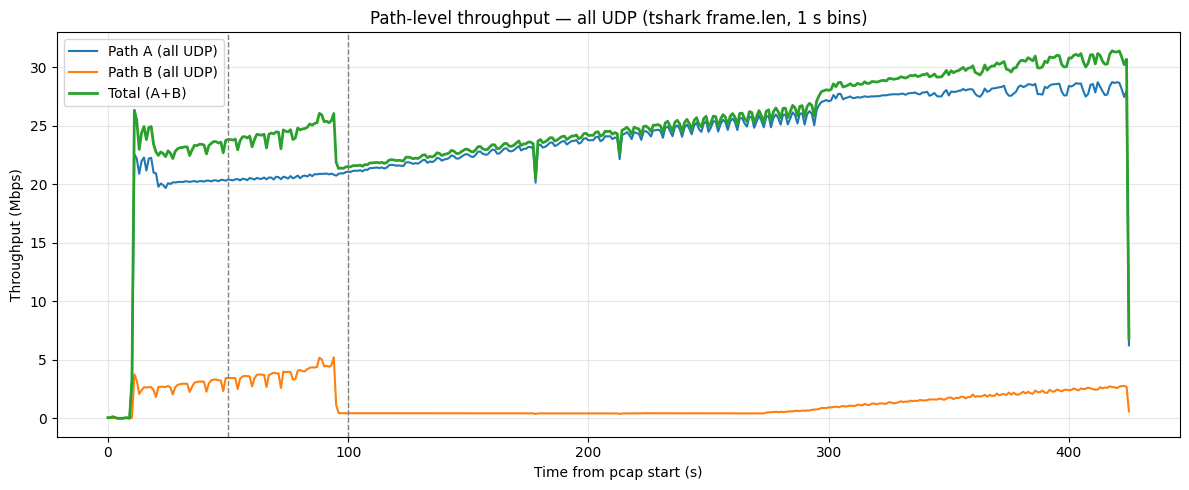

saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_20260517_233010/fig7_um_t/csv/throughput_all_udp_1s.png


In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df1["second"], df1["pathA_all_udp_mbps"], label="Path A (all UDP)")
plt.plot(df1["second"], df1["pathB_all_udp_mbps"], label="Path B (all UDP)")
plt.plot(df1["second"], df1["total_all_udp_mbps"], label="Total (A+B)", linewidth=2)
plt.axvline(50, linestyle="--", linewidth=1, color="gray")
plt.axvline(100, linestyle="--", linewidth=1, color="gray")
plt.xlabel("Time from pcap start (s)")
plt.ylabel("Throughput (Mbps)")
plt.title("Path-level throughput — all UDP (tshark frame.len, 1 s bins)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_1S, dpi=200)
plt.show()
print("saved", FIG_1S)